# Plots

## 1. Spectrogram plot 
Database Recording

In [1]:
import os
import librosa
import numpy as np
import matplotlib.pyplot as plt

import sys

sys.path.append('../src')
from fingerprint_build import AudioExtract, FingerPrintBuild

/home/eadenise/Documents/work_repo/audio_identification/myvenv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


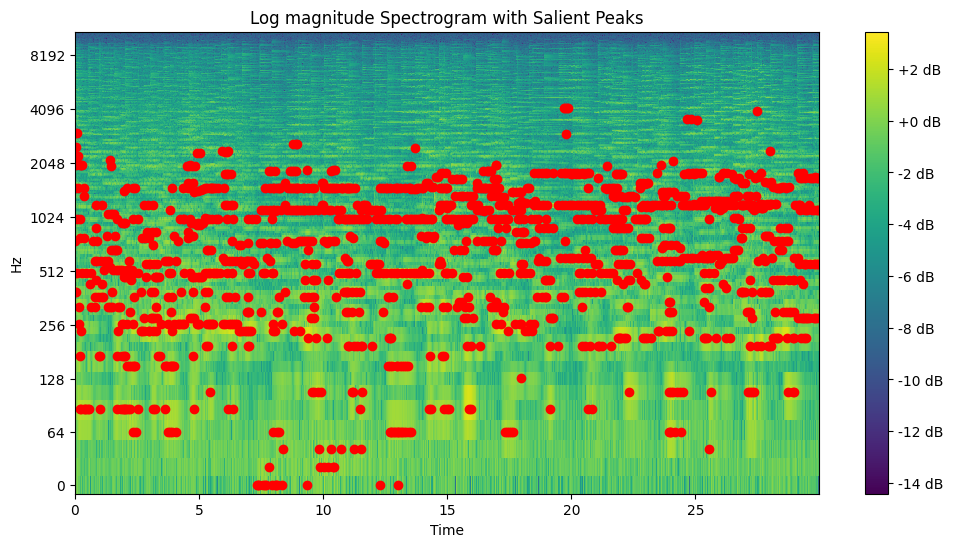

In [4]:
sr = 22050
n_fft = 1024
hop_length = n_fft // 2
window_sec = 1
spec = AudioExtract(sr, n_fft, hop_length)

database_dir = '../data/database_recordings/'
sample_file = os.path.join(database_dir, 'classical.00001.wav')

y = spec.get_single_file(sample_file)

fp = FingerPrintBuild(y)
peaks = fp.get_salient_peaks(sr, hop_length, target_peak_s = 50, window_sec=window_sec) 
bin_idx, frame_idx = zip(*peaks)

times = librosa.frames_to_time(frame_idx, sr=sr, hop_length=hop_length)
freqs = librosa.fft_frequencies(sr=sr, n_fft=n_fft)[list(bin_idx)]

fig, ax = plt.subplots(1, 1, figsize=(12,6))
img = librosa.display.specshow(y, y_axis='log',x_axis='time',
                               sr=sr, ax=ax, cmap='viridis')

ax.scatter(x=times, y= freqs, c='red')
fig.colorbar(img, ax=ax, format='%+2.0f dB')                           
ax.set(title='Log magnitude Spectrogram with Salient Peaks')
plt.show()

